In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
#the code is written with help of copilot for learning basic concepts in ML

In [2]:

# ----------------------------------
# Load data from CSV
# ----------------------------------
data = pd.read_csv("data_2026.csv")

X = data[['X']]           # Feature (must be 2D)
Y = data['Y']
Z = data['Z']

In [3]:
print(data)

    X   Y      Z
0   1   2  0.125
1   2   4  0.250
2   3   6  0.375
3   4   8  0.500
4   5  10  0.625
5   6  12  0.750
6   7  14  0.875
7   8  16  1.000
8   9  18  1.125
9  10  20  1.250


In [4]:
# ----------------------------------
# Train linear regression models
# ----------------------------------
model_y = LinearRegression()
model_z = LinearRegression()

model_y.fit(X, Y)
model_z.fit(X, Z)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
# ----------------------------------
# New input for prediction
# ----------------------------------

new_x_value = 12
new_x = np.array([[new_x_value]])

predicted_y = model_y.predict(new_x)[0]
predicted_z = model_z.predict(new_x)[0]

print(f"Input X = {new_x_value}")
print(f"Predicted Y = {predicted_y}")
print(f"Predicted Z = {predicted_z}")

Input X = 12
Predicted Y = 24.000000000000007
Predicted Z = 1.5000000000000004


/home/govardhanks/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/govardhanks/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [8]:
# Output the linear regression summary for better understanding
#summary = model_y.summary()
# Print or save this to a file as needed

print("Y model: Y =", model_y.coef_[0], "* X +", model_y.intercept_)
print("Z model: Z =", model_z.coef_[0], "* X +", model_z.intercept_)

# Output the regression summary for better understanding
#summary = model_y.summary()
# Print or save this to a file as needed
coef_y, std_err_y, t_score_y, p_value_y = model_y.score()
print(f"Y model: Coefficient (beta): {model_y.coef_[0]}, Std Error: {std_err_y}, T-Statistic (t-score): {t_score_y}, P-value: {p_value_y}")

coef_z, std_err_z, t_score_z, p_value_z = model_z.score()
print(f"Z model: Coefficient (beta): {model_z.coef_[0]}, Std Error: {std_err_z}, T-Statistic (t-score): {t_score_z}, P-value: {p_value_z}")

Y model: Y = 2.0000000000000004 * X + -1.7763568394002505e-15
Z model: Z = 0.12500000000000003 * X + -1.1102230246251565e-16


TypeError: RegressorMixin.score() missing 2 required positional arguments: 'X' and 'y'

In [7]:
# ----------------------------------
# Create smooth X range for plots
# ----------------------------------
x_range = np.linspace(X.min().values[0], new_x_value, 100).reshape(-1, 1)

y_pred_line = model_y.predict(x_range)
z_pred_line = model_z.predict(x_range)

/home/govardhanks/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/govardhanks/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


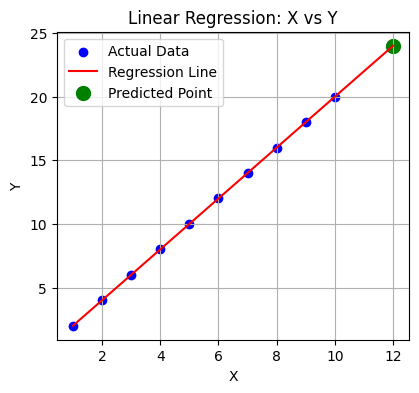

In [8]:
# ----------------------------------
# Plot 1: X vs Y
# ----------------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(x_range, y_pred_line, color='red', label='Regression Line')
plt.scatter(new_x_value, predicted_y, color='green', s=100, label='Predicted Point')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression: X vs Y")
plt.legend()
plt.grid(True)

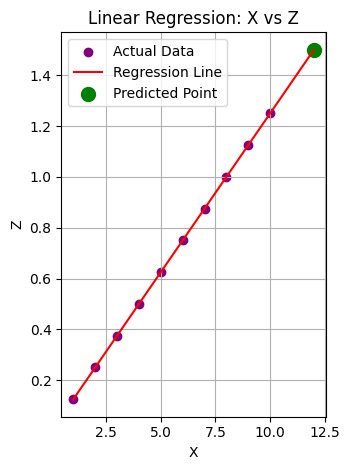

In [9]:

# ----------------------------------
# Plot 2: X vs Z
# ----------------------------------
plt.subplot(1, 2, 2)
plt.scatter(X, Z, color='purple', label='Actual Data')
plt.plot(x_range, z_pred_line, color='red', label='Regression Line')
plt.scatter(new_x_value, predicted_z, color='green', s=100, label='Predicted Point')
plt.xlabel("X")
plt.ylabel("Z")
plt.title("Linear Regression: X vs Z")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
#What Each Plot Explains
# Blue / Purple dots
# ➡ Original data from CSV
# Red line
# ➡ Learned ML regression model
# Green dot
# ➡ Prediction for new X value
# This visually answers:
# Does the data look linear?
# Did the model learn correctly?
# Where does the new prediction fall relative to known data?



In [11]:
print("Y model: Y =", model_y.coef_[0], "* X +", model_y.intercept_)
print("Z model: Z =", model_z.coef_[0], "* X +", model_z.intercept_)

Y model: Y = 2.0000000000000004 * X + -1.7763568394002505e-15
Z model: Z = 0.12500000000000003 * X + -1.1102230246251565e-16


In [10]:
import statsmodels.api as sm

# Add constant for intercept
X_sm = sm.add_constant(X)

model_y = sm.OLS(Y, X_sm).fit()

print(model_y.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.589e+31
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          6.75e-124
Time:                        09:56:33   Log-Likelihood:                 321.22
No. Observations:                  10   AIC:                            -638.4
Df Residuals:                       8   BIC:                            -637.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const               0   2.07e-15          0      1.0

/home/govardhanks/test/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [1]:
!wget https://www.statlearning.com/s/Advertising.csv

--2026-04-23 07:10:18--  https://www.statlearning.com/s/Advertising.csv
Resolving www.statlearning.com (www.statlearning.com)... 

198.49.23.144, 198.49.23.145, 198.185.159.144, ...
Connecting to www.statlearning.com (www.statlearning.com)|198.49.23.144|:443... 

connected.


HTTP request sent, awaiting response... 

302 Found
Location: https://static1.squarespace.com/static/5ff2adbe3fe4fe33db902812/t/5fffe03b4091076ff5b30c72/1610604603901/Advertising.csv [following]
--2026-04-23 07:10:19--  https://static1.squarespace.com/static/5ff2adbe3fe4fe33db902812/t/5fffe03b4091076ff5b30c72/1610604603901/Advertising.csv
Resolving static1.squarespace.com (static1.squarespace.com)... 151.101.192.238, 151.101.0.238, 151.101.64.238, ...
Connecting to static1.squarespace.com (static1.squarespace.com)|151.101.192.238|:443... connected.
HTTP request sent, awaiting response... 

200 OK
Length: 4555 (4.4K) [text/csv]
Saving to: ‘Advertising.csv’

Advertising.csv     100%[===================>]   4.45K  --.-KB/s    in 0s      

2026-04-23 07:10:20 (97.9 MB/s) - ‘Advertising.csv’ saved [4555/4555]



In [2]:
!head Advertising.csv

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
6,8.7,48.9,75,7.2
7,57.5,32.8,23.5,11.8
8,120.2,19.6,11.6,13.2
9,8.6,2.1,1,4.8


In [3]:
!cp Advertising.csv /mnt/c/users/govardhan.kothapalli/Documents/Machine\ Learning